# 14장 실습 — 더 나아가기 (이진화·델타·FF·NIR)

**Spiking Neural Networks 쿡북 with Python** · 14장 실습 노트북

심화 주제 네 가지를 짧은 레시피로 맛본다 — **이진화(BSNN)**, **델타 뉴런**, **Forward-Forward**, **NIR 내보내기**. 각 절은 독립적이다.

### 학습 목표
- 가중치를 +1/−1로 이진화하는 STE를 구현한다.
- `snn.DeltaLeaky`와 일반 LIF의 발화를 비교한다.
- Forward-Forward의 goodness 개념을 확인한다.


## 1. 설치와 임포트

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
import snntorch as snn
from snntorch import utils
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. 이진화 SNN (BSNN) — 가중치를 +1/−1로

부호 함수로 가중치를 +1 또는 −1로 만든다. 부호 함수는 미분이 0이라, 역전파에서는 기울기를 그대로 통과시키는 **STE(straight-through estimator)**로 우회한다. 전체 정밀도 가중치와 이진화 결과를 비교해 본다.

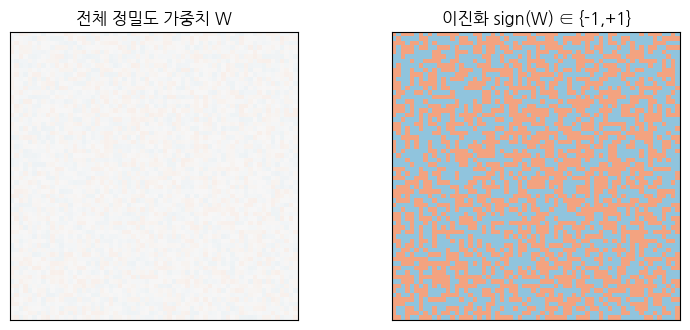

In [2]:
class Binarize(Function):
    @staticmethod
    def forward(ctx, weight):
        return weight.sign().clamp(min=-1)      # +1 또는 -1

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone()              # STE: 기울기를 그대로 통과

class BinaryLinear(nn.Linear):
    def forward(self, x):
        return F.linear(x, Binarize.apply(self.weight))   # 이진화 가중치로 선형 변환

layer = BinaryLinear(64, 64, bias=False)
W = layer.weight.detach()
Wb = Binarize.apply(layer.weight).detach()

fig, (a0, a1) = plt.subplots(1, 2, figsize=(8, 3.4))
a0.imshow(
    W, cmap='RdBu', 
    vmin=-2.5, vmax=2.5
); a0.set_title('전체 정밀도 가중치 W'); a0.set_xticks([]); a0.set_yticks([])
a1.imshow(
    Wb, cmap='RdBu', 
    vmin=-2.5, vmax=2.5
); a1.set_title('이진화 sign(W) ∈ {-1,+1}'); a1.set_xticks([]); a1.set_yticks([])
plt.tight_layout(); plt.show()

## 3. 델타 뉴런 (DeltaLeaky) vs 일반 LIF

`snn.DeltaLeaky`는 막전위가 **직전 발화 이후 일정량 이상 변했을 때**만 발화한다. 같은 계단 입력을 두 뉴런에 주고 출력 스파이크를 비교한다. 델타 뉴런이 변화 순간에만 더 드물게 발화하는 것을 볼 수 있다.

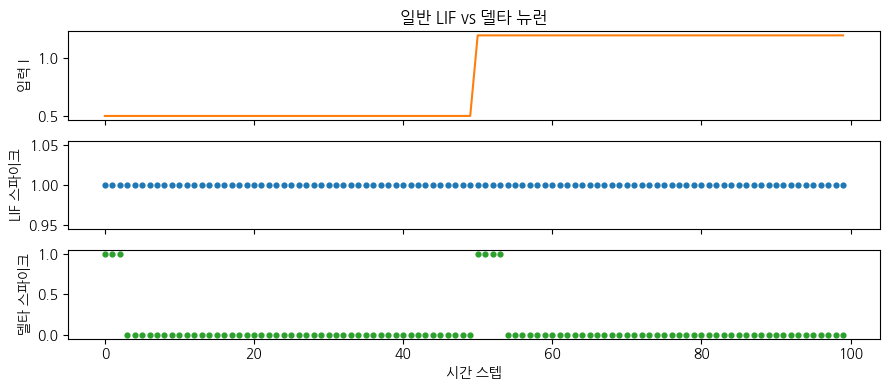

In [3]:
num_steps = 100
cur_in = torch.ones(num_steps) * 0.5
cur_in[num_steps // 2:] = 1.2          # 중간에 입력이 커짐(변화 발생)

leaky = snn.Leaky(beta=0.8, threshold=0.3, init_hidden=True, output=True)
delta = snn.DeltaLeaky(beta=0.8, delta_threshold=0.3, init_hidden=True, output=True)

def run_spikes(neuron):
    utils.reset(neuron)
    spk_rec = []
    for step in range(num_steps):
        spk_out, mem_out = neuron(cur_in[step])
        spk_rec.append(spk_out)
    return torch.stack(spk_rec).detach()

leaky_spk = run_spikes(leaky)
delta_spk = run_spikes(delta)

fig, (a0, a1, a2) = plt.subplots(3, 1, figsize=(9, 4), sharex=True)
a0.plot(cur_in, color='tab:orange'); a0.set_ylabel('입력 I'); a0.set_title('일반 LIF vs 델타 뉴런')
a1.scatter(range(num_steps), leaky_spk, color='tab:blue', s=12); a1.set_ylabel('LIF 스파이크')
a2.scatter(range(num_steps), delta_spk, color='tab:green', s=12); a2.set_ylabel('델타 스파이크'); a2.set_xlabel('시간 스텝')
plt.tight_layout(); plt.show()

## 4. Forward-Forward — goodness로 학습

역전파 대신 **양성/음성 샘플**을 흘려 학습한다. 입력의 앞 10픽셀에 레이블을 덧씌워 양성(올바른 레이블)·음성(틀린 레이블) 샘플을 만들고, 스파이킹 층의 **goodness**(활성 제곱합)가 양성에는 높게, 음성에는 낮게 나오도록 한 층을 국소 학습한다.

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0,), (1,)),
                                transforms.Lambda(lambda x: torch.flatten(x))])
mnist = datasets.MNIST('/tmp/data/mnist', train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=256, shuffle=True)

def overlay_y_on_x(x, y):
    x_ = x.clone()
    x_[:, :10] = 0.0                       # 앞 10픽셀을 비우고
    x_[range(x.shape[0]), y] = x.max()     # 레이블 위치만 활성화
    return x_

x, y = next(iter(loader))
y_wrong = y[torch.randperm(y.size(0))]     # 섞은(틀린) 레이블
x_pos = overlay_y_on_x(x, y)               # 양성 샘플
x_neg = overlay_y_on_x(x, y_wrong)         # 음성 샘플
print('양성/음성 샘플 형태:', tuple(x_pos.shape))

양성/음성 샘플 형태: (256, 784)


학습 후 양성-음성 goodness 차이: 0.027


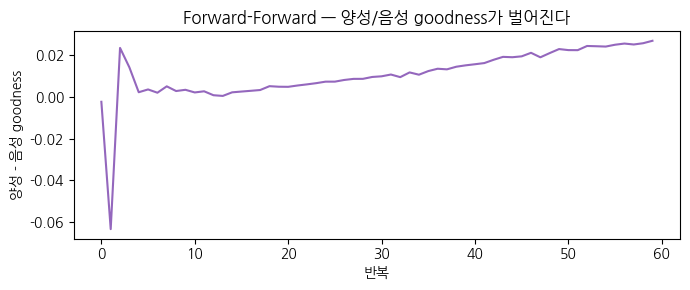

In [5]:
layer = nn.Linear(784, 500, bias=False)
lif = snn.Leaky(beta=0.8)
ff_steps = 10

def layer_goodness(x):
    mem = lif.init_leaky()
    spk_sum = 0
    for step in range(ff_steps):
        spk, mem = lif(layer(x), mem)      # 한 층을 여러 스텝 통과
        spk_sum = spk_sum + spk
    return (spk_sum ** 2).mean(dim=1)      # 샘플별 goodness

optimizer = torch.optim.Adam(layer.parameters(), lr=0.02)
threshold = 2.0
gap_hist = []

for iteration in range(60):
    g_pos = layer_goodness(x_pos)
    g_neg = layer_goodness(x_neg)
    # 양성 goodness는 임계 위로, 음성은 아래로
    loss = (F.softplus(threshold - g_pos) + F.softplus(g_neg - threshold)).mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    gap_hist.append((g_pos.mean() - g_neg.mean()).item())

print(f'학습 후 양성-음성 goodness 차이: {gap_hist[-1]:.3f}')

plt.figure(figsize=(7, 3))
plt.plot(gap_hist, color='tab:purple')
plt.xlabel('반복'); plt.ylabel('양성 - 음성 goodness')
plt.title('Forward-Forward — 양성/음성 goodness가 벌어진다'); plt.tight_layout(); plt.show()

## 정리

- **이진화**: 부호 함수로 가중치를 +1/−1로 만들고 STE로 학습한다.
- **델타 뉴런**: 변화가 있을 때만 발화해 더 희소하다.
- **Forward-Forward**: 양성/음성 goodness 차이를 키워 역전파 없이 학습한다.
- **NIR**: 모델을 표준 포맷으로 내보내 다른 프레임워크·하드웨어로 잇는다.